In [232]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [233]:
import torch
np.random.seed(75)
torch.manual_seed(75)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name())
    torch.cuda.manual_seed(75)
    device = "cuda"
else:
    device = "cpu"

NVIDIA GeForce RTX 4060 Laptop GPU


In [234]:
url = "https://raw.githubusercontent.com/aiplanethub/Datasets/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)


In [235]:
X = df.drop(["Churn" , "customerID"] , axis=1)
y = df["Churn"]

X["TotalCharges"] = pd.to_numeric(
    X["TotalCharges"], errors="coerce"
)

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , stratify = y)

print(f"X_train : {X_train.shape} , X_test : {X_test.shape}\ny_train : {y_train.shape} , y_test : {y_test.shape}")

X_train : (4930, 19) , X_test : (2113, 19)
y_train : (4930,) , y_test : (2113,)


In [236]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Preprocessing

In [237]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=["number"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Fit on training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

X_train shape: (4930, 45)
X_test shape: (2113, 45)


In [238]:


# Convert target labels to NumPy arrays
y_train_np = y_train.map({"No": 0, "Yes": 1}).to_numpy(dtype=np.float32)
y_test_np = y_test.map({"No": 0, "Yes": 1}).to_numpy(dtype=np.float32)

# Check shapes
print("X_train:", X_train_np.shape)
print("X_test:", X_test_np.shape)
print("y_train:", y_train_np.shape)
print("y_test:", y_test_np.shape)

# Check data types
print(type(X_train_np))
print(type(y_train_np))

X_train: (4930, 4668)
X_test: (2113, 4668)
y_train: (4930,)
y_test: (2113,)
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [239]:
X_train_tensor = torch.from_numpy(X_train_processed).float().to(device)
X_test_tensor = torch.from_numpy(X_test_processed).float().to(device)
y_train_tensor = torch.from_numpy(y_train_np).float().to(device)
y_test_tensor = torch.from_numpy(y_test_np).float().to(device)

In [240]:
X_train_tensor.shape

torch.Size([4930, 45])

In [241]:
BATCH_SIZE = 32
NUM_WORKER = 3

from torch.utils.data import TensorDataset , DataLoader

train_data = TensorDataset(X_train_tensor , y_train_tensor)
test_data = TensorDataset(X_test_tensor , y_test_tensor)


train_loader = DataLoader(
    dataset = train_data,
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKER,
    shuffle = True
)

test_loader = DataLoader(
    dataset = test_data,
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKER,
    shuffle = True
)

### Model Creation

In [242]:
import torch.nn as nn
class ChurnPredictor(nn.Module):

    def __init__(self , input_size , hidden_size = [256 , 128 , 64] , dropout_rate = 0.2):
        super().__init__()

        layers = []

        prev_size = input_size

        for i , hidden_size in enumerate(hidden_size):

            # Linear Layer
            layer = nn.Linear(prev_size , hidden_size)
            layers.append(layer)

            # Batch Normalization
            batch_norm = nn.BatchNorm1d(hidden_size)
            layers.append(batch_norm)

            # Activation
            relu = nn.ReLU()
            layers.append(relu)

            # Dropout
            dropout = nn.Dropout(dropout_rate)
            layers.append(dropout)

            prev_size = hidden_size

        # output layer
        output_layer = nn.Linear(prev_size , 1)
        layers.append(output_layer)
        # activation = nn.Sigmoid()

        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        # Xavier/Glorot initialization 
        for module in self.modules():
            
            if isinstance(module , nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias , 0)

    def forward(self , x):
        return self.network(x).squeeze(1)


In [243]:
input_size = X_train_tensor.shape[1]
print(f"Input Features : {input_size}")

model = ChurnPredictor(
    input_size = input_size,
    hidden_size = [256 , 128 , 64],
    dropout_rate = 0.2
).to(device)

print(f"Model Created and moved to : {device} \n")

print(f"Total Parameters : { sum( p.numel() for p in model.parameters() ) }\n")

print("Model Architecture:->")
print(model)

import numpy as np

negative_count = np.sum(y_train_np == 0)
positive_count = np.sum(y_train_np == 1)

class_weight_dict = {
    0: 1.0,
    1: negative_count / positive_count
}


from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.optim as optim

pos_weight_tensor = torch.tensor(
    [class_weight_dict[1]],
    dtype = torch.float,
).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight = pos_weight_tensor
)

optimizer = optim.SGD(
    lr = 0.00015,
    params = model.parameters(),
    weight_decay = 1e-5
)

scheduler = ReduceLROnPlateau(
    optimizer , mode = "min" ,
    factor = 0.5 , patience = 10
)



Input Features : 45
Model Created and moved to : cuda 

Total Parameters : 53889

Model Architecture:->
ChurnPredictor(
  (network): Sequential(
    (0): Linear(in_features=45, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training Loop

In [244]:
BATCH_SIZE = 32
NUM_WORKERS = 0

from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset( X_train_tensor , y_train_tensor )
test_dataset = TensorDataset( X_test_tensor , y_test_tensor )

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    shuffle = True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    shuffle = True
)

def train_model(
    EPOCH = 50 , model = model , optimizer = optimizer , criterion = criterion , 
    train_loader = train_loader , test_loader = test_loader 
):


    train_loss = []
    val_loss = []

    for epoch in range(1 , EPOCH + 1):

        model.train()

        total_loss = 0

        for X_train_batch , y_train_batch in train_loader:

            pred = model(X_train_batch)

            loss = criterion(pred , y_train_batch)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        scheduler.step(avg_loss)
        print(f"Epoch : {epoch}/{EPOCH} - Training Loss : {avg_loss:.3f}")
        train_loss.append(avg_loss)

        model.eval()

        with torch.inference_mode():
            
            total_loss = 0

            for X_test_batch , y_test_batch in test_loader:

                pred = model(X_test_batch)
                loss = criterion(pred , y_test_batch)

                total_loss+=loss.item()

            avg_loss = total_loss / len(test_loader)
            print(f"Epoch : {epoch}/{EPOCH} - Validation Loss : {avg_loss:.3f}")
            val_loss.append(avg_loss)         


    return train_loss , val_loss


In [245]:
train_loss , val_loss = train_model()

Epoch : 1/50 - Training Loss : 1.205
Epoch : 1/50 - Validation Loss : 1.062
Epoch : 2/50 - Training Loss : 1.150
Epoch : 2/50 - Validation Loss : 1.090
Epoch : 3/50 - Training Loss : 1.106
Epoch : 3/50 - Validation Loss : 0.978
Epoch : 4/50 - Training Loss : 1.066
Epoch : 4/50 - Validation Loss : 0.954
Epoch : 5/50 - Training Loss : 1.041
Epoch : 5/50 - Validation Loss : 0.930
Epoch : 6/50 - Training Loss : 1.018
Epoch : 6/50 - Validation Loss : 0.902
Epoch : 7/50 - Training Loss : 0.993
Epoch : 7/50 - Validation Loss : 0.901
Epoch : 8/50 - Training Loss : 0.963
Epoch : 8/50 - Validation Loss : 0.863
Epoch : 9/50 - Training Loss : 0.968
Epoch : 9/50 - Validation Loss : 0.859
Epoch : 10/50 - Training Loss : 0.936
Epoch : 10/50 - Validation Loss : 0.839
Epoch : 11/50 - Training Loss : 0.920
Epoch : 11/50 - Validation Loss : 0.851
Epoch : 12/50 - Training Loss : 0.928
Epoch : 12/50 - Validation Loss : 0.862
Epoch : 13/50 - Training Loss : 0.929
Epoch : 13/50 - Validation Loss : 0.821
Epoc

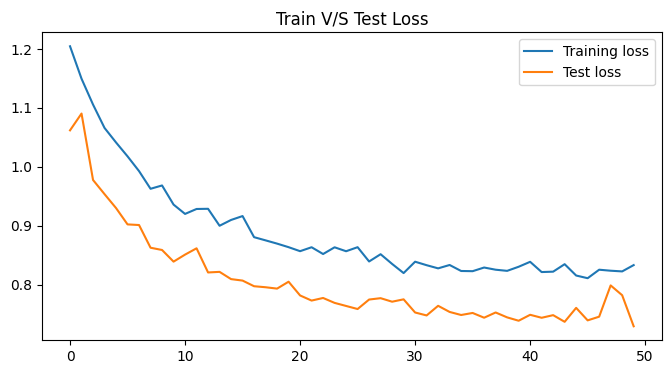

In [246]:
plt.figure(figsize = (8, 4))
plt.title("Train V/S Test Loss")
plt.plot(train_loss , label = "Training loss")
plt.plot(val_loss , label = "Test loss")
plt.legend()
plt.show()

In [247]:
!pip install torchview


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



(process:42196): Pango-WARNING **: 04:39:35.681: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


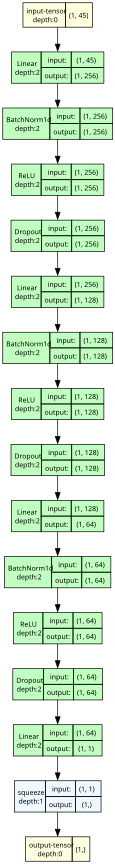

In [248]:
from torchview import draw_graph

model_graph = draw_graph(
    model,
    input_size=(1, input_size),
    device=device
)

model_graph.visual_graph